# Python Basic

<br>

## Package verisoning

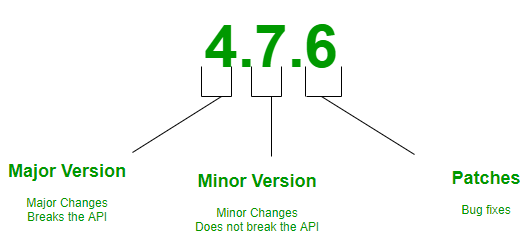

- Verzionisanje paketa se vrsi pomoci 3 broja [Major, Minor, Patch]
- Promene `Major` broja znace da novi paket uvodi velike promene i da nece biti kompatibilana sa prethodnin -- recimo python 2.7 vs 3.9
- Promene `Minor` broja su recimo dodavanje novih funkcionalnosti, pravljenje velikih refactora koda
- Promene `Patch` broja su uglavnom bug fixes na postojecim funkcionalnostima koje nece promeniti interfejs
- Biblioteke koje pocinju sa vodecom `0.*.*` su jos u ranoj fazi razvoja i svaka promena moze da bude nekompatibilna
    - tek kad prva cifra postane `1.*.*` - onda je API za biblioteku dobio oblik i nece biti nekompatibilnih promena u istoj Major verziji

<br>

## ID - vraca adresu u memoriji na kojoj se objekat nalazi

In [1]:
id(1)

94641370327976

In [2]:
id('This is a sentence')

139860998932080

In [3]:
id(print)

139861073434224

In [4]:
neka_klasa = object()
id(neka_klasa)

139860999770048

### Python Optimization Intering


- Sam pajton kao jezik radi odredjene optimizacije, jedna od njih je da integre od -5 do 256 kesira u memoriji (svaka instanca broja iz ovog opsega uvek ce pokazivati na istu memorijsku adresu)
- Neka ideja jeste da se ovi manji brojevi cesto koriste i da je brze da odmah budeu u memoriji (da se izbegne proces zauzimanja memorije za njih)

In [5]:
id_1 = id(256)
id_2 = id(256)
f'{id_1=} <=> {id_2=}'

'id_1=94641370336136 <=> id_2=94641370336136'

In [6]:
id_1 = id(350)
id_2 = id(350)
f'{id_1=} <=> {id_2=}'

'id_1=139860999054352 <=> id_2=139860999051888'

- Isto tako radi kesiranje kratih stringova iz istih razloga -- samo njih radi prvi put kad se koriste umseto odmah na pocetku pokretanaj

In [7]:
id_1 = id('Filip')
id_2 = id('Filip')
f'{id_1=} <=> {id_2=}'

'id_1=139860999417264 <=> id_2=139860999417264'

In [8]:
id_1 = id('Nekad, davno, bas davno, u vreme kad su postojala 2 Meseca...')
id_2 = id('Nekad, davno, bas davno, u vreme kad su postojala 2 Meseca...')
f'{id_1=} <=> {id_2=}'

'id_1=139860999374640 <=> id_2=139860999374416'

<br>

## `IS` (identity) vs `==` (value) comparison

- `is` proverava da li su objekti na istoj memorijskoj adresi
- `==` poziva `__eq__` metodu koja proverava po vrednosti

In [9]:
a = 1000
b = a
a == b, a is b

(True, True)

In [10]:
a = 1000
b = 1000
a == b, a is b

(True, False)

In [11]:
# ako uzmemo prethodno da je 10 uvek kesirano i ovo ce biti tacno
a = 10
b = 10
a == b, a is b

(True, True)

<br>

## TYPE - vraca tip objekta

In [12]:
type(1)

int

In [13]:
type('Mesec')

str

In [14]:
class Person:
    "Person example class"

p_1 = Person()
type(p_1)

__main__.Person

<br>

## HELP - ispisuje dokumentaciju funkcije

In [15]:
help(print)

Help on built-in function print in module builtins:

print(*args, sep=' ', end='\n', file=None, flush=False)
    Prints the values to a stream, or to sys.stdout by default.
    
    sep
      string inserted between values, default a space.
    end
      string appended after the last value, default a newline.
    file
      a file-like object (stream); defaults to the current sys.stdout.
    flush
      whether to forcibly flush the stream.



In [16]:
help(id)

Help on built-in function id in module builtins:

id(obj, /)
    Return the identity of an object.
    
    This is guaranteed to be unique among simultaneously existing objects.
    (CPython uses the object's memory address.)



In [17]:
# u jupyter-u slicno moze da se dobije sa operatorom `??`
??id

Signature: id(obj, /)
Docstring:
Return the identity of an object.

This is guaranteed to be unique among simultaneously existing objects.
(CPython uses the object's memory address.)
Type:      builtin_function_or_method

<br>

## PRINT - ispisuje na standardni izlaz

In [18]:
print('Nekad je tako bilo jednom nesto')

Nekad je tako bilo jednom nesto


In [19]:
# u jupyter-u poslednje linija koja nije dodeljena se ispisuje [koristeci njihovu display funkciju]
poslednja_linija = 'Mesec je na nebu'
poslednja_linija

'Mesec je na nebu'

<br>

## DIR 

In [20]:
??dir

Docstring:
dir([object]) -> list of strings

If called without an argument, return the names in the current scope.
Else, return an alphabetized list of names comprising (some of) the attributes
of the given object, and of attributes reachable from it.
If the object supplies a method named __dir__, it will be used; otherwise
the default dir() logic is used and returns:
  for a module object: the module's attributes.
  for a class object:  its attributes, and recursively the attributes
    of its bases.
  for any other object: its attributes, its class's attributes, and
    recursively the attributes of its class's base classes.
Type:      builtin_function_or_method

In [21]:
dir(p_1)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__']

In [22]:
print(f' {p_1.__class__=} \n {p_1.__str__()=} \n {p_1.__doc__=}')

 p_1.__class__=<class '__main__.Person'> 
 p_1.__str__()='<__main__.Person object at 0x7f33ec13dcd0>' 
 p_1.__doc__='Person example class'


<br>

## ISSUBCLASS

In [23]:
??issubclass

Signature: issubclass(cls, class_or_tuple, /)
Docstring:
Return whether 'cls' is derived from another class or is the same class.

A tuple, as in ``issubclass(x, (A, B, ...))``, may be given as the target to
check against. This is equivalent to ``issubclass(x, A) or issubclass(x, B)
or ...``.
Type:      builtin_function_or_method

In [24]:
issubclass(int, object)

True

In [25]:
issubclass(str, object)

True

<br>

## SYS

In [26]:
import sys
??sys

Type:        module
String form: <module 'sys' (built-in)>
Docstring:  
This module provides access to some objects used or maintained by the
interpreter and to functions that interact strongly with the interpreter.

Dynamic objects:

argv -- command line arguments; argv[0] is the script pathname if known
path -- module search path; path[0] is the script directory, else ''
modules -- dictionary of loaded modules

displayhook -- called to show results in an interactive session
excepthook -- called to handle any uncaught exception other than SystemExit
  To customize printing in an interactive session or to install a custom
  top-level exception handler, assign other functions to replace these.

stdin -- standard input file object; used by input()
stdout -- standard output file object; used by print()
stderr -- standard error object; used for error messages
  By assigning other file objects (or objects that behave like files)
  to these, it is possible to redirect all of the interpreter'

In [27]:
# Ispisuje verziju pajtona
sys.version_info

sys.version_info(major=3, minor=11, micro=6, releaselevel='final', serial=0)

In [28]:
# Prikazuje informacije o float implementaciji
sys.float_info

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)

In [29]:
# 'Prikazuje gde ce interpreter gledati da pronadje pakete i biblioteke
sys.path

['/home/filip/python_projects/ucimo',
 '/home/filip/miniconda3/envs/ucimo_pajton/lib/python311.zip',
 '/home/filip/miniconda3/envs/ucimo_pajton/lib/python3.11',
 '/home/filip/miniconda3/envs/ucimo_pajton/lib/python3.11/lib-dynload',
 '',
 '/home/filip/miniconda3/envs/ucimo_pajton/lib/python3.11/site-packages']

<br>

## 1. Data Types

### 1.1 Numbers

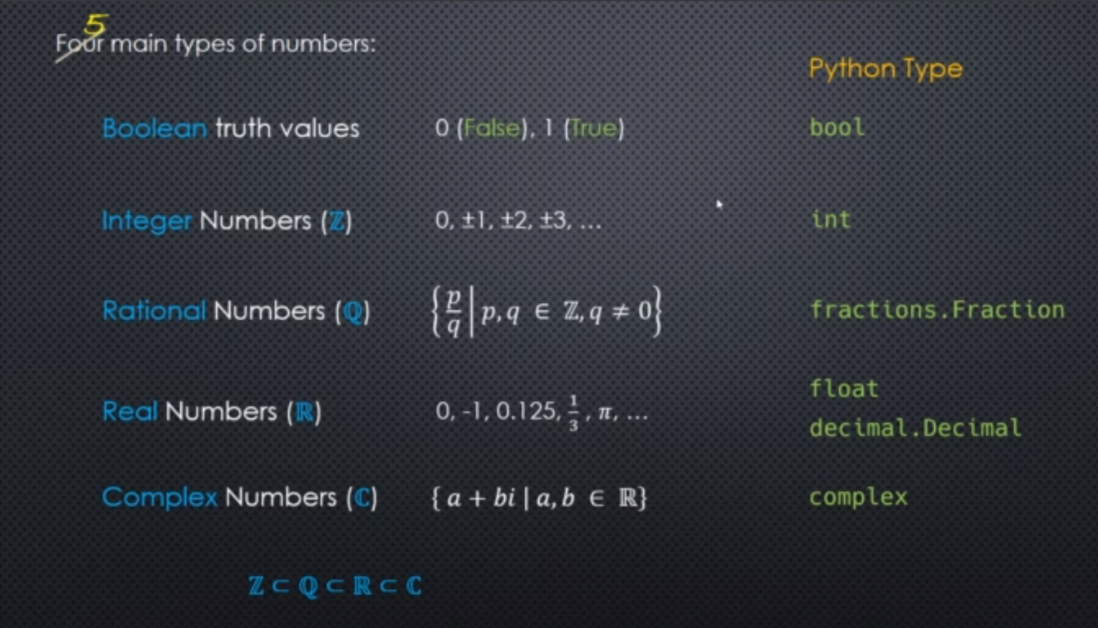

#### Int - celobrojni brojevi

In [30]:
x = 3131
type(x)

int

In [31]:
# brojevi zarad lakse citljivosti mogu se pisati sa _
x = 31_333_000_000_000
x

31333000000000

In [32]:
# mogu se koristiti i binarna i heksadecimalna notacija
x = 0b101000110100111
y = 0xab103
f'binarni broj {x=} --- heksadecimalni broj {y=}'

'binarni broj x=20903 --- heksadecimalni broj y=700675'

In [33]:
# casting -- pajton je lower bound
int(2.43434), int(2.8989889), int(3.4324), int(3.99)

(2, 2, 3, 3)

#### Flaot - realni brojevi

In [34]:
x = 21.21513124
type(x)

float

In [35]:
# matematicko / bankarsko zaokruzivanje
# racio --> zamislite banka i da vam se na milion transakcija uvek zaokruzi na vecu... u gubitku ste pola miliona
round(1.5), round(2.5), round(3.5), round(4.5)

(2, 2, 4, 4)

In [36]:
# greska float brojeva prilikom zaokruzivanja -- nesposobni su da prikazu tacno sve brojeve
0.1 + 0.1 + 0.1 == 0.3

False

#### Decimal - realni brojevi

- resavaju problem preciznosti

In [37]:
from decimal import Decimal
x = Decimal(0.1)
f'{type(x)=} -- {x=}'

"type(x)=<class 'decimal.Decimal'> -- x=Decimal('0.1000000000000000055511151231257827021181583404541015625')"

In [38]:
x = Decimal('0.1')
print(f'{type(x)=} -- {x=}')
Decimal('0.1') + Decimal('0.1') + Decimal('0.1') == Decimal('0.3')

type(x)=<class 'decimal.Decimal'> -- x=Decimal('0.1')


True

#### Bool - tacno i netacno

In [39]:
# da bool je u pajtonu podklasa broja
print(f'{issubclass(bool, int)=}')
print(f'method_resolution_order={bool.__mro__}')

issubclass(bool, int)=True
method_resolution_order=(<class 'bool'>, <class 'int'>, <class 'object'>)


In [40]:
# True je 1, a False je 0
True == 1, False == 0, True == 5, False == -3

(True, True, False, False)

In [41]:
True + True + True - False

3

In [42]:
3 - (2*True) + 2 

3

In [43]:
# bool vrednosti su isto Singltoni

a = False
b = False
a == b, a is b, id(a), id(b)

(True, True, 94641370325792, 94641370325792)

#### Objekti u pythonu su Truthy i Falsy

In [44]:
# These are falsy
my_list = []
my_dict = {}
my_set = set()
my_tuple = tuple()
zero = 0
false = False
none = None
my_str = ""

# Basically the rest are truthy, example:
my_second_list = ["foo"]

if len(my_list) == 0:
    print(f"Empty list is so empty -- Dont to it this way -- {(len(my_list) == 0)=}")

if not my_list:
    print(f"Empty list is so empty -- Do it this way -- {(not my_list)=}")

if my_second_list:
    print(f"This should be true -- Do it this way")

ten = 10
if ten:
    print(f'{bool(ten)}')

Empty list is so empty -- Dont to it this way -- (len(my_list) == 0)=True
Empty list is so empty -- Do it this way -- (not my_list)=True
This should be true -- Do it this way
True


### 1.2 Strings

In [45]:
my_string_double = "Python is my favorite programming language! in double quotes"
my_string_single = 'Python is my favorite programming language! in single quotes'

print("2 ways to write string so you can use ' character inside string without escapes")

type(my_string_double), type(my_string_single)

2 ways to write string so you can use ' character inside string without escapes


(str, str)

#### 1.2.1 Escapes

In [46]:
print("Escapes are done with \ so \t will write tab \\\\t will write \\t and if we want text in new line \n -- we use the \\n")

Escapes are done with \ so 	 will write tab \\t will write \t and if we want text in new line 
 -- we use the \n


#### 1.2.2 Multiline

In [47]:
# respecting PEP 8
long_story = (
    "Lorem ipsum dolor sit amet, consectetur adipiscing elit."
    "Pellentesque eget tincidunt felis. Ut ac vestibulum est."
    "In sed ipsum sit amet sapien scelerisque bibendum. Sed "
    "sagittis purus eu diam fermentum pellentesque."
)
print(long_story)

Lorem ipsum dolor sit amet, consectetur adipiscing elit.Pellentesque eget tincidunt felis. Ut ac vestibulum est.In sed ipsum sit amet sapien scelerisque bibendum. Sed sagittis purus eu diam fermentum pellentesque.


In [48]:
# dont do this, but its possible
long_story = "Lorem ipsum dolor sit amet, consectetur adipiscing elit." \
             "Pellentesque eget tincidunt felis. Ut ac vestibulum est." \
             "In sed ipsum sit amet sapien scelerisque bibendum. Sed " \
             "sagittis purus eu diam fermentum pellentesque."
print(long_story)

Lorem ipsum dolor sit amet, consectetur adipiscing elit.Pellentesque eget tincidunt felis. Ut ac vestibulum est.In sed ipsum sit amet sapien scelerisque bibendum. Sed sagittis purus eu diam fermentum pellentesque.


In [49]:
# will add new lines
long_story = """Lorem ipsum dolor sit amet, consectetur adipiscing elit.
Pellentesque eget tincidunt felis. Ut ac vestibulum est.
In sed ipsum sit amet sapien scelerisque bibendum. Sed
sagittis purus eu diam fermentum pellentesque.
"""
print(long_story)

Lorem ipsum dolor sit amet, consectetur adipiscing elit.
Pellentesque eget tincidunt felis. Ut ac vestibulum est.
In sed ipsum sit amet sapien scelerisque bibendum. Sed
sagittis purus eu diam fermentum pellentesque.



#### 1.2.3 F-Strings -- the best strings

In [50]:
first_name = "Mesec"
last_name = "Sa Sunca"
f"My name is {first_name} {last_name}, you can call me {first_name}."

'My name is Mesec Sa Sunca, you can call me Mesec.'

In [51]:
# alternative
print("My name is {first_name} {last_name}, you can call me {first_name}.".format(first_name=first_name, last_name=last_name))
# alternativa bez imenovanja
print("My name is {} {}, you can call me {}.".format(first_name, last_name, first_name))

My name is Mesec Sa Sunca, you can call me Mesec.
My name is Mesec Sa Sunca, you can call me Mesec.


In [52]:
# number formatting
print(f'Poletanje na Mesec za: {2.57832443298523479:0.4f}')

# string formatting
print(f'Next sentence will take 30 characters and be moved to right--> {"Filip":>30}')

Poletanje na Mesec za: 2.5783
Next sentence will take 30 characters and be moved to right-->                          Filip


#### 1.2.4 Some string functions

In [53]:
# join
x = " - ".join(['Tamo', 'je', 'jednom', 'bilo', 'jako', 'lepo'])
print(x, end='\n\n')

# upper, lower, title, capitalize
mixed_case = "PyTHoN hackER"
print(f" {mixed_case=} \n {mixed_case.upper()=} \n {mixed_case.lower()=} \n {mixed_case.title()=} \n {mixed_case.capitalize()=}")

Tamo - je - jednom - bilo - jako - lepo

 mixed_case='PyTHoN hackER' 
 mixed_case.upper()='PYTHON HACKER' 
 mixed_case.lower()='python hacker' 
 mixed_case.title()='Python Hacker' 
 mixed_case.capitalize()='Python hacker'


In [54]:
# strip -- remove whitespace, new lines, tabs at start and end of string
ugly_formatted = " \n \t           Some story to tell      \n"
stripped = ugly_formatted.strip()

print(f"ugly: {ugly_formatted}")
print(f"stripped: {stripped}")

ugly:  
 	           Some story to tell      

stripped: Some story to tell


In [55]:
# split
print("U krateru Meseca spavao je ...".split())
print("U krateru - Meseca - spavao je ...".split('-'))

['U', 'krateru', 'Meseca', 'spavao', 'je', '...']
['U krateru ', ' Meseca ', ' spavao je ...']


In [56]:
# replace
"U krateru Meseca spavao je ...".replace('spavao', 'ziveo')

'U krateru Meseca ziveo je ...'

In [57]:
# ofc you can chain functions -- order matters
"   ThIS LooKs BAd ".strip().lower().replace("bad", "good")

'this looks good'

### 1.3 Collections

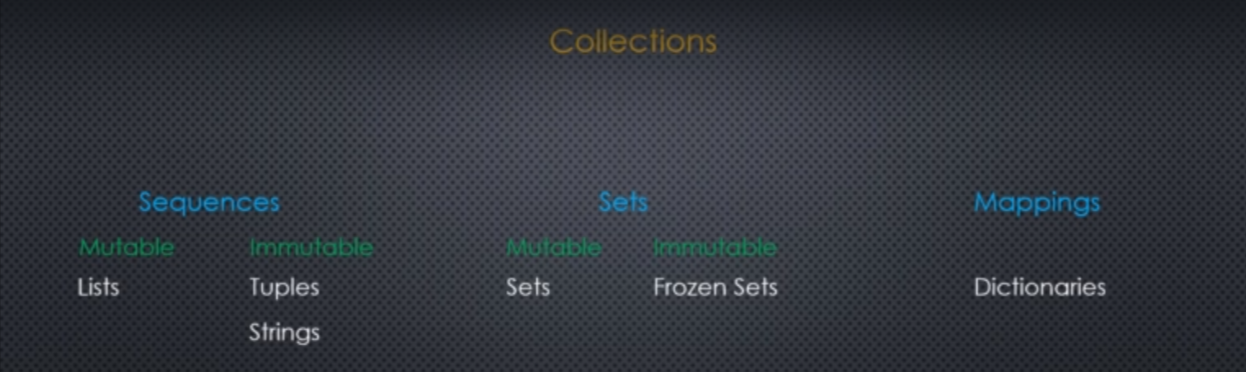

#### 1.3.1 Tuple

In [58]:
x = (2, 3)
y = 2, 3
type(x), type(y)

(tuple, tuple)

In [59]:
# pristupanje elementima
print(x[0])
print(y[1])

2
3


In [60]:
# unpacking
a, b = (2, 3)
print(a)
print(b)

2
3


In [61]:
from collections import namedtuple
Koordinate = namedtuple('Koordinate', 'x y')

xy_koordinata = Koordinate(1, 3)
xy_koordinata

Koordinate(x=1, y=3)

In [62]:
# sada moze da se pristupa preko imena
print(xy_koordinata.x)

# naravno moze i dalje da se indeksira
print(xy_koordinata[-1])

1
3


#### 1.3.2 List

In [63]:
my_empty_list = []
print(f"empty list: {my_empty_list},   type: {type(my_empty_list)},   bool: {bool(my_empty_list)}")

empty list: [],   type: <class 'list'>,   bool: False


In [64]:
filled_list = ["Jednom", "davno", "na", "Mesecu", "je", "ziveo"]
print(f"list: {filled_list},   length: {len(filled_list)},   type: {type(filled_list)},   bool: {bool(filled_list)}")

list: ['Jednom', 'davno', 'na', 'Mesecu', 'je', 'ziveo'],   length: 6,   type: <class 'list'>,   bool: True


In [65]:
# acessing and slicing
print(filled_list[0])
print(filled_list[3])

# slicing [lower_bound:upperbound:step] - lower_bound <= ... < upperbound
print(filled_list[3:6])

# reversing list
print(filled_list[::-1])

# inplace reverse
filled_list.reverse()
print(filled_list)

Jednom
Mesecu
['Mesecu', 'je', 'ziveo']
['ziveo', 'je', 'Mesecu', 'na', 'davno', 'Jednom']
['ziveo', 'je', 'Mesecu', 'na', 'davno', 'Jednom']


In [66]:
# list is mutable 
x = [1, 2, 3, 'Mesec']
print(id(x))

x.append(42)
print(id(x))

139860981250944
139860981250944


In [67]:
# changing element
print(x)
x[4] = 'Answer to the Ultimate Question of Life, the Universe, and Everything'
print(x)

[1, 2, 3, 'Mesec', 42]
[1, 2, 3, 'Mesec', 'Answer to the Ultimate Question of Life, the Universe, and Everything']


In [68]:
# joining 2 lists
print([1,2,3] + [5,6,7])

x = [1,2,3]
x.extend([5,6,7])
print(x)

[1, 2, 3, 5, 6, 7]
[1, 2, 3, 5, 6, 7]


In [69]:
# + creates new list
x = [1,2,3]
y = [1,2,3]

print(id(x), id(y))
z = x +y
id(z)

139860980923648 139860981236672


139860980910656

In [70]:
# extends mutates list
x = [1,2,3]
y = [1,2,3]

print(id(x), id(y))
x.extend(y)
id(x)

139860981239872 139860980658304


139860981239872

In [71]:
# += inplace operator, mitates list
x = [1,2,3]
y = [1,2,3]

print(id(x), id(y))
y += x
id(y)

139860980910848 139860981295680


139860981295680

In [72]:
# checking if something is in the list
print(f"""
{12 in [1,2,3]=}
{3 in [1,2,3]=}
""")


12 in [1,2,3]=False
3 in [1,2,3]=True



In [73]:
# remove elements
filled_list = ["Jednom", "davno", "na", "Mesecu", "je", "ziveo"]
filled_list.remove("davno")
filled_list

['Jednom', 'na', 'Mesecu', 'je', 'ziveo']

In [74]:
# sort list
numbers = [3, 1, 7, 5, 10]
numbers.sort()
numbers

[1, 3, 5, 7, 10]

##### 1.3.2.1 Python Optimization List Memory Prealocation

In [75]:
# pajton radi optimizacije za svaku listu zauzme vise mesta nego sto treba u zelji da prosirivanje liste bude brze
# koliko vise mesta zauzme zavisi od velicine liste sto veca lista vise mesta prealocira za dodatna prosirenja

import sys
lst = list()
print('list size:', f'{sys.getsizeof(lst)} byets,', 'list:', lst)

for x in range(20):
    lst.append(x)
    print('list size:', f'{sys.getsizeof(lst)} byets,', 'list:', lst)

list size: 56 byets, list: []
list size: 88 byets, list: [0]
list size: 88 byets, list: [0, 1]
list size: 88 byets, list: [0, 1, 2]
list size: 88 byets, list: [0, 1, 2, 3]
list size: 120 byets, list: [0, 1, 2, 3, 4]
list size: 120 byets, list: [0, 1, 2, 3, 4, 5]
list size: 120 byets, list: [0, 1, 2, 3, 4, 5, 6]
list size: 120 byets, list: [0, 1, 2, 3, 4, 5, 6, 7]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
list size: 184 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
list size: 248 byets, list: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15

#### 1.3.3 List vs Tuples

##### 1.3.3.1 Hasing

In [76]:
# tuples can be hashed
hash(xy_koordinata)

-1440771752368011620

In [77]:
try:
    hash([1,2,3])
except Exception as e:
    print(e)
    print('Lists can not be hased')

unhashable type: 'list'
Lists can not be hased


##### 1.3.3.1 Tuple vs List compile

In [78]:
# u pozadini sta kompajler radi, i da je tuple vise optimizovan

from dis import dis
tuple_code = '(1,2,3)'
list_code = '[1,2,3]'
tuple_code_m = '(1,[0,0,0],3)'

print('tuple python compile')
dis(compile(tuple_code, filename='string', mode='eval'))

print('\n\nlist python compile')
dis(compile(list_code, filename='string', mode='eval'))

print('\n\nwhen you put mutable types in tuple you lose this')
dis(compile(tuple_code_m, filename='string', mode='eval'))

tuple python compile
  0           0 RESUME                   0

  1           2 LOAD_CONST               0 ((1, 2, 3))
              4 RETURN_VALUE


list python compile
  0           0 RESUME                   0

  1           2 BUILD_LIST               0
              4 LOAD_CONST               0 ((1, 2, 3))
              6 LIST_EXTEND              1
              8 RETURN_VALUE


when you put mutable types in tuple you lose this
  0           0 RESUME                   0

  1           2 LOAD_CONST               0 (1)
              4 BUILD_LIST               0
              6 LOAD_CONST               1 ((0, 0, 0))
              8 LIST_EXTEND              1
             10 LOAD_CONST               2 (3)
             12 BUILD_TUPLE              3
             14 RETURN_VALUE


#### 1.3.4 Sets

In [79]:
my_empty_set = set()
print(f"{my_empty_set=},   type: {type(my_empty_set)},   bool: {bool(my_empty_set)}")

my_empty_set=set(),   type: <class 'set'>,   bool: False


In [80]:
filled_set = {"Jednom", "davno", "na", "Mesecu", "je", "ziveo"}
print(f"list: {filled_set},   length: {len(filled_set)},   type: {type(filled_set)},   bool: {bool(filled_set)}")

list: {'na', 'je', 'davno', 'Mesecu', 'Jednom', 'ziveo'},   length: 6,   type: <class 'set'>,   bool: True


In [81]:
try:
    hash({1,2,3})
except Exception as e:
    print(e)
    print('Sets can not be hased')

unhashable type: 'set'
Sets can not be hased


In [82]:
# checking if something is in the set
set1 = {1,2,3}
1 in set1

True

In [83]:
try:
    set1[1]
except Exception as e:
    print(e)
    print('Sets dont have ordered indexing')

'set' object is not subscriptable
Sets dont have ordered indexing


##### 1.3.4.1 IN speed comparison Set vs List

In [84]:
set1 = {*range(10_000)}
list1 = list(range(10_000))

print(f'{len(set1)=} -- {len(list1)=}')

len(set1)=10000 -- len(list1)=10000


In [85]:
# marvel at the spped of set search
%timeit for x in range(1000): 999 in set1

47.4 µs ± 7.13 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [86]:
# slow list searcj
%timeit for x in range(1000): 999 in list1

9.11 ms ± 337 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


#### 1.3.5 Dictionaries

- In python Dictionaries save order of entry

In [87]:
my_empty_dict = {}  # alternative: my_empty_dict = dict()
print(f"{my_empty_dict=},   type: {type(my_empty_dict)},   bool: {bool(my_empty_dict)}")

my_empty_dict={},   type: <class 'dict'>,   bool: False


In [88]:
filled_dict = {'key_1':'Mesec', 'key_2':'Sunce'}  # alternative: my_empty_dict = dict()
print(f"list: {filled_dict},   length: {len(filled_dict)},   type: {type(filled_dict)},   bool: {bool(filled_dict)}")

list: {'key_1': 'Mesec', 'key_2': 'Sunce'},   length: 2,   type: <class 'dict'>,   bool: True


In [89]:
print(f"keys: {filled_dict.keys()}")
print(f"values: {filled_dict.values()}")
print(f"items: {filled_dict.items()}")

keys: dict_keys(['key_1', 'key_2'])
values: dict_values(['Mesec', 'Sunce'])
items: dict_items([('key_1', 'Mesec'), ('key_2', 'Sunce')])


In [90]:
my_dict = {"key_1":'Mesec', "key_3":'Mars'}
my_dict["key_2"] = 1000
my_dict["key_3"] = "Sunce"  # overriding existing value

print(my_dict)
print(f"{my_dict['key_1']=}")

{'key_1': 'Mesec', 'key_3': 'Sunce', 'key_2': 1000}
my_dict['key_1']='Mesec'


In [91]:
# dict get to acess values, doesnt raise error when key is not present
print(f'{my_dict.get("key_3")=}')
print(f'{my_dict.get("key_100")=}')
print(f'{my_dict.get("key_100", "Default Value")=}')

my_dict.get("key_3")='Sunce'
my_dict.get("key_100")=None
my_dict.get("key_100", "Default Value")='Default Value'


In [92]:
# pythonic dict iterration -- look at the order it is preserved
for key, val in my_dict.items():
    print(key, '-', val)

key_1 - Mesec
key_3 - Sunce
key_2 - 1000


In [93]:
# marvel at the spped of dict search
dicto = {x:x for x in range(10_000)}

%timeit for x in range(1000): 999 in dicto

49.5 µs ± 1.53 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [94]:
# dict keys must be hashable (imutable)
print({(1,2):'sadas'}, end='\n\n')

try:
    {[1,2]:'sadas'}
except Exception as e:
    print(e)
    print('Dict keys must be hasable')

{(1, 2): 'sadas'}

unhashable type: 'list'
Dict keys must be hasable


In [95]:
# deleting keys from dict
my_dict = {"key_1":'Mesec', "key_3":'Mars', "key_2":2, "key_4":4, "key_5":5}
print(f'{my_dict=}', end='\n\n')

del my_dict['key_2']
print(f'{my_dict=} -- after del', end='\n\n')

key_5_val = my_dict.pop("key_5")
print(f"{my_dict=} -- after pop -- {key_5_val=}")

my_dict={'key_1': 'Mesec', 'key_3': 'Mars', 'key_2': 2, 'key_4': 4, 'key_5': 5}

my_dict={'key_1': 'Mesec', 'key_3': 'Mars', 'key_4': 4, 'key_5': 5} -- after del

my_dict={'key_1': 'Mesec', 'key_3': 'Mars', 'key_4': 4} -- after pop -- key_5_val=5


In [96]:
# joining dicts
dict1 = {'key_1':1, 'key_2':2, 'key_3':3}
dict2 = {'key_4':4, 'key_5':5, 'key_3':300}

print(f'{dict1 | dict2=}')

merged_dict = {**dict1, **dict2}
print(f'{{**dict1, **dict2}}={merged_dict}')

dict1 | dict2={'key_1': 1, 'key_2': 2, 'key_3': 300, 'key_4': 4, 'key_5': 5}
{**dict1, **dict2}={'key_1': 1, 'key_2': 2, 'key_3': 300, 'key_4': 4, 'key_5': 5}


In [97]:
try:
    hash({'key1':1, 'key2':2})
except Exception as e:
    print(e)
    print('Dicts can not be hased')

unhashable type: 'dict'
Dicts can not be hased


## 2. Variable names

 - case sensitive: `my_var` != `my_Var`
 - must start with: `_`, `a-z`, `A-Z` (can not start with number, after 1st character you can use numbers `0-9`)
 - can be reserved words: `None`, `True`, `False`, `not`, `if`, `else`, `return` ...
 - 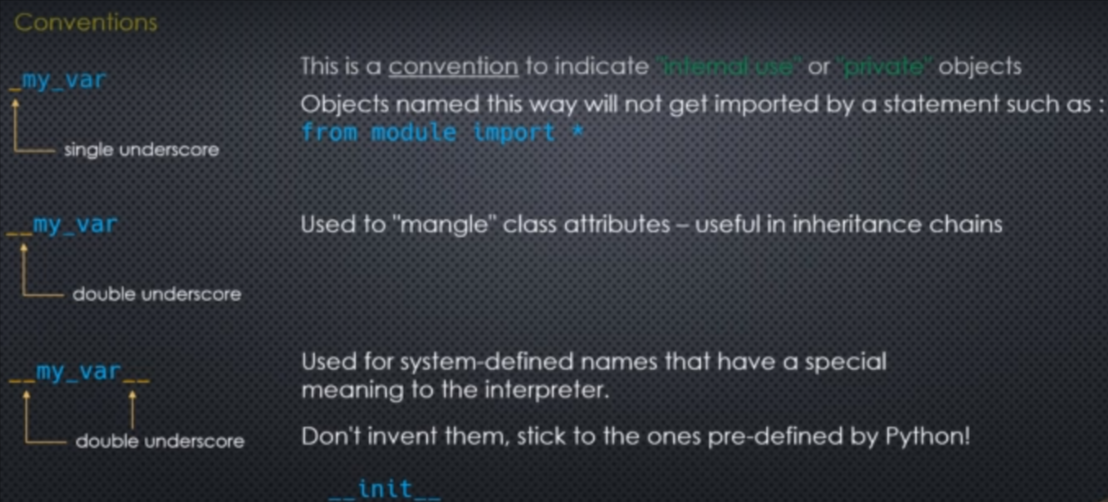
 - 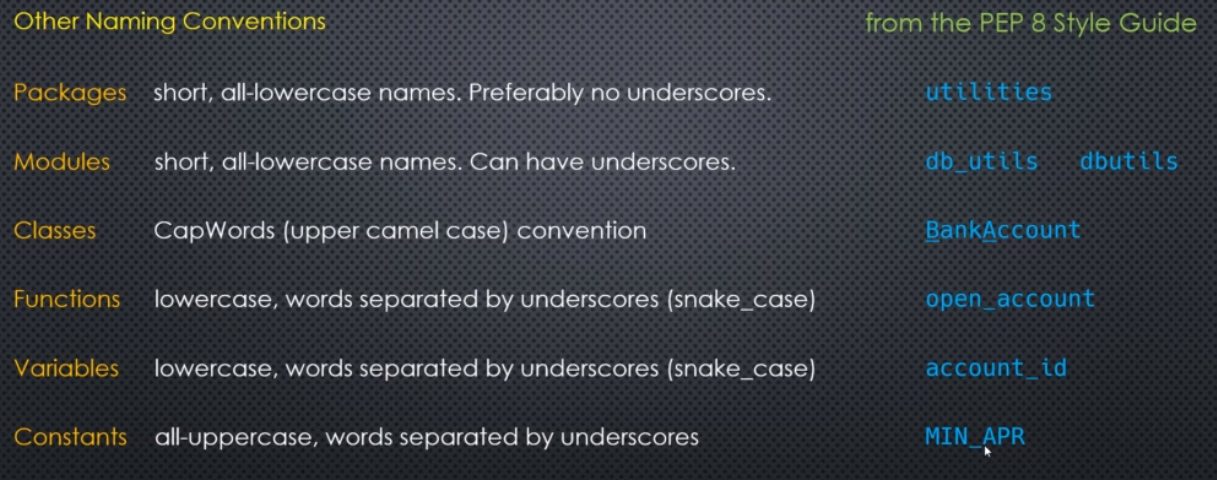

In [98]:
class ABC_CLASS:
    def __method_name(self):
        "This method will have name of class before its name --> _ABC_CLASS_method_name"

    def _private_method(self):
        "This method is indication that it is privete and should be used only in class"

    def __len__(self):
        return 0

ABC_CLASS.__dict__.keys()

dict_keys(['__module__', '_ABC_CLASS__method_name', '_private_method', '__len__', '__dict__', '__weakref__', '__doc__'])

In [99]:
# implementing __len__ we change what bool returns since 0 iz False
instance_1 = ABC_CLASS()
print(f'Dunder (__method__) methods are used by python --> for instance __len__ is used in truthfulness\n\n check {bool(instance_1)=}')


class ABC_CLASS:
    "Not touching __len__"
instance_2 = ABC_CLASS()
print(f' check {bool(instance_2)=}')

Dunder (__method__) methods are used by python --> for instance __len__ is used in truthfulness

 check bool(instance_1)=False
 check bool(instance_2)=True


## 3. Operations

In [100]:
1 + 2

3

In [101]:
432432 / 34

12718.588235294117

In [102]:
432432 // 34

12718

In [103]:
432432 % 34

20

In [104]:
True and False

False

In [105]:
not True

False

In [106]:
True or False

True

In [107]:
all([True, False])

False

In [108]:
any([True, False])

True

### 3.1 Pyhton Optimization Short Circuiting

In [109]:
# doesnt raise error since or needs just one to be True (and first one is True - doesnt check after expressions)
True or non_existing_variable 

True

In [110]:
try:
    non_existing_variable or True
except Exception as e:
    print(e)

name 'non_existing_variable' is not defined


### 3.2 Pythonic way of assiging values

In [111]:
# or stops at first true or last element
x = None or 0 or []
y = None or 10 or []
print(f'{x=}, {y=}')

x=[], y=10


In [112]:
# and stops at first false or last element
x = "I am good" and 0 and []
y = "I am good" and 10 and [1,2,3]
print(f'{x=}, {y=}')

x=0, y=[1, 2, 3]


### 3.3 Inpalce operators

In [113]:
# for Imutable types it will create new variable
x = 103213
print(f'{id(x)}, {x=}')

x += 3123
print(f'{id(x)}, {x=}')

139860980355216, x=103213
139860980356048, x=106336


In [114]:
# for Mutable types it will create change existing variable
x = [103213]
print(f'{id(x)}, {x=}')

x += [3123]
print(f'{id(x)}, {x=}')

139860980903168, x=[103213]
139860980903168, x=[103213, 3123]


## 4. Flow Control

### 1. If - elif - else

```python
if <condition>:
    <code>
elif <condition>:
    <code>
elif <condition>:
    <code>

    .
    .
    .
    
else:
    <code>
```

In [115]:
val = 88
if val >= 100:
    print("value is equal or greater than 100")
elif val > 10:
    print("value is greater than 10 but less than 100")
else:
    print("value is equal or less than 10")

value is greater than 10 but less than 100


### 2. Ternary operator

```python
<statement> if <condition> else <statement>
```

In [116]:
x = 3 if 5 > 10 else 1
x

1

### 3. While loop 

```python
while <condition>:
    <code>
else:
    # if while loop doesnt break it will execute code here
    <code>
```
`else part is optional`

In [117]:
i = 0
while i < 4:
    i += 1    
    print(i)

1
2
3
4


In [118]:
i = 0
while i < 4:
    i += 1    
    print(i)
else:
    print('It will execute since break wont happen')

1
2
3
4
It will execute since break wont happen


In [119]:
i = 0
while i < 4:
    i += 1    
    print(i)
    if i==3:
        break
else:
    print('It wont execute since there is a break')

1
2
3


### 4. For - loop?

```python
for <variables> in <collection>:
    <code>
else:
    # if for loop doesnt break it will execute code here
    <code>
```
`else part is optional`

In [120]:
for x in range(5):
    print(x)

0
1
2
3
4


In [121]:
for x in range(3, 8):
    print(x)
else:
    print('Nije bilo brejka -- pa ce se izvrsiti')

3
4
5
6
7
Nije bilo brejka -- pa ce se izvrsiti


In [122]:
for x in range(3, 8):
    print(x)
    if x == 5:
        break
else:
    print('Nije bilo brejka -- pa nece izvrsiti')

3
4
5


#### 4.1 Enumerate

In [123]:
for pos, val in enumerate([1,2,3,4,5]):
    print(f'{pos} - {val}')

0 - 1
1 - 2
2 - 3
3 - 4
4 - 5


## 5. Functions

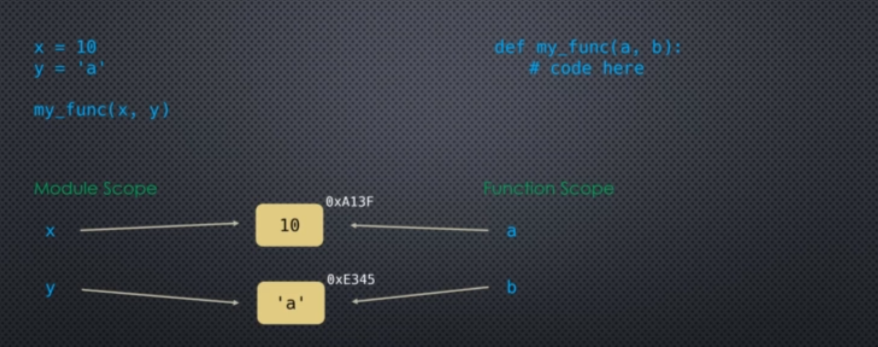

### 5.1 Arguments vs Parameters

-- parametri su u definiciji funkcije

-- argumenti su ono sto se prosledjuje kada se poziva funkcija

In [124]:
def func(a, b=None, /):
    """Docstring of funtion"""
    print('a, b su parametri funkcije func')
    print('-- b je samo parametar sa defaultnom vrednosti -- sto znaci ne mora da se navede')
    print(f'{a=}, {b=}')
    print()

In [125]:
func(4, 'Mesec')
print('func(4, "Mesec") ==> `4` i `Mesec` pozicioni argumenti sa kojim se poziva funkcija')

a, b su parametri funkcije func
-- b je samo parametar sa defaultnom vrednosti -- sto znaci ne mora da se navede
a=4, b='Mesec'

func(4, "Mesec") ==> `4` i `Mesec` pozicioni argumenti sa kojim se poziva funkcija


In [126]:
func(4)
print('func(4) ==> `4` je pozicioni argument, a za `b` se uzme defaultna vrednost')

a, b su parametri funkcije func
-- b je samo parametar sa defaultnom vrednosti -- sto znaci ne mora da se navede
a=4, b=None

func(4) ==> `4` je pozicioni argument, a za `b` se uzme defaultna vrednost


In [127]:
# znaci b u definiciji nije keyword argument -- ono je samo parametar sa defaultnom vrednosti
# -- tek prilikom pozivanja funkcije imamo argumente koji mogu biti pozicioni i keyword
try:
    print('Ako bi sad pokusali da prosledimo `b` kao keyword argument fejlovali bi')
    print('/ u definiciji funkcije nalaze da pre nje priliom poziva funkcije moraju da se navedu samo pozicioni argument i to max 2', end='\n\n')
    func(4, b='Mesec')
except Exception as e:
    print(e)

Ako bi sad pokusali da prosledimo `b` kao keyword argument fejlovali bi
/ u definiciji funkcije nalaze da pre nje priliom poziva funkcije moraju da se navedu samo pozicioni argument i to max 2

func() got some positional-only arguments passed as keyword arguments: 'b'


In [128]:
try:
    print('Prosledjivanjem 3ceg pozicionog argumenta ce isto izazvati greski', end='\n\n')
    func(4, 'Mesec', 5)
except Exception as e:
    print(e)

Prosledjivanjem 3ceg pozicionog argumenta ce isto izazvati greski

func() takes from 1 to 2 positional arguments but 3 were given


### 5.2 Positional and Keyword Arguments

In [129]:
def func(a, b, c=10, d=None):
    print(f'{a=}, {b=}, {c=}, {d=}')

"a, b, c, d su parametri -- pri tome c i d su parametri sa defaultnom vrednosti"

'a, b, c, d su parametri -- pri tome c i d su parametri sa defaultnom vrednosti'

In [130]:
func(a, c=10, d=None, b=3)

"a je pozicioni argument -- b, c, d su prosledjeni kao keyword argumenti -- zato sto imaju ime b ce biti dobro mapirano"

a=2, b=3, c=10, d=None


'a je pozicioni argument -- b, c, d su prosledjeni kao keyword argumenti -- zato sto imaju ime b ce biti dobro mapirano'

### 5.3. Unpacking

In [131]:
a, *b = [1,2,3,4,5,6]
a, b

(1, [2, 3, 4, 5, 6])

In [132]:
*a, b = [1,2,3,4,5,6]
a, b

([1, 2, 3, 4, 5], 6)

In [133]:
a, *b, c = [1,2,3,4,5,6]
a, b, c

(1, [2, 3, 4, 5], 6)

In [134]:
[*[1,2,3,4], 1, 2, 3]

[1, 2, 3, 4, 1, 2, 3]

In [135]:
*a, b, (c1, c2, c3) = [1,2,3,4,5,6, (1,2,3)]
a, b, c1, c2, c3

([1, 2, 3, 4, 5], 6, 1, 2, 3)

In [136]:
# keyword argument unpackig -- unpacks key value pairs
{**{'key1':1, 'key2':1}}

{'key1': 1, 'key2': 1}

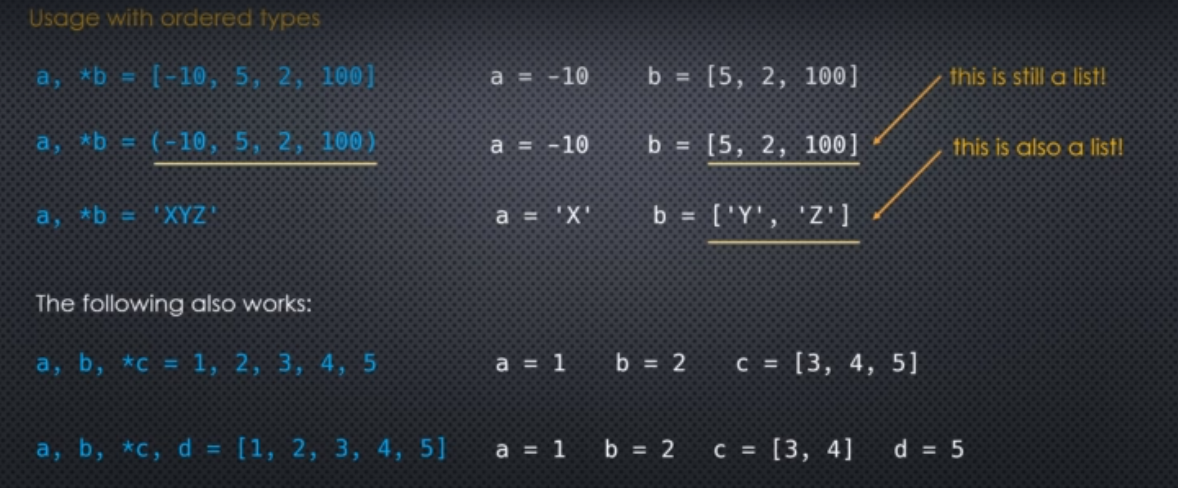

### 5.4 *args and **kwargs

In [137]:
# takes one positional argument that must be passed, others can be passed as positional or keyword
def func_1(a, /, b, c=None):
    print(f'{a=}, {b=}, {c=}')

func_1(1, 2)
func_1(1, 3, 4)
func_1(1, c=3, b=4)
try:
    # a must be passed as positional argument
    func_1(1, a=3, b=4)
except Exception as e:
    print(e)

a=1, b=2, c=None
a=1, b=3, c=4
a=1, b=4, c=3
func_1() got some positional-only arguments passed as keyword arguments: 'a'


In [138]:
# takes first postitional argument and puts it to a, all others positional arguments are in *args
def func_1(a, *args):
    print(f'{a=}, {args=}')

func_1(1, 2, 3, 4, 5, 6, 7)

a=1, args=(2, 3, 4, 5, 6, 7)


In [139]:
# takes first postitional argument and puts it to a, forces all other arguments to be keyword
# def func_1(a, *): -- this is syntax error

def func_1(a, *, b, c):
    print(f'{a=}, {b=}, {c=}')

func_1(1, c=2, b=7)
# note difference no slash -- so we can pass a as keyword
func_1(b=1, c=2, a=7)

try:
    # b, c must be passed as keyword arguments
    func_1(1, 3, 4)
except Exception as e:
    print(e)

a=1, b=7, c=2
a=7, b=1, c=2
func_1() takes 1 positional argument but 3 were given


In [140]:
def func(param1, param2, /, param3=None, *, param4, param5, **kwargs):
    print(f'{param1=}, {param2=}, {param3=}, {param4=}, {param5=}, {kwargs=}')

# param1, param2 -- must be passed as positional arguments
# param3 - can be passed as positional or keyword argument
# param4, param5 -- must be passed as keyword arguments
# **kwargs -- collect all rest keyword argument

func(1, 2, 3, param4='Mesec', param5='Sunce', kw1=1, kw2=2, kw3=3)
func(1, 2, param3=3, param4='Mesec', param5='Sunce', kw1=1, kw2=2, kw3=3)

param1=1, param2=2, param3=3, param4='Mesec', param5='Sunce', kwargs={'kw1': 1, 'kw2': 2, 'kw3': 3}
param1=1, param2=2, param3=3, param4='Mesec', param5='Sunce', kwargs={'kw1': 1, 'kw2': 2, 'kw3': 3}
